In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed_data'

nav   = pd.read_csv(PROCESSED_DIR / 'clean_nav.csv', parse_dates=['date'])
fund  = pd.read_csv(PROCESSED_DIR / 'clean_fund_master.csv')
txn   = pd.read_csv(PROCESSED_DIR / 'clean_transactions.csv', parse_dates=['transaction_date'])
perf  = pd.read_csv(PROCESSED_DIR / 'clean_performance.csv')
port  = pd.read_csv(PROCESSED_DIR / 'clean_portfolio_holdings.csv')

nav = nav.sort_values(['amfi_code','date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print("✅ Data loaded")

✅ Data loaded


In [2]:
var_results = []

for code in nav['amfi_code'].unique():
    returns = nav[nav['amfi_code']==code]['daily_return'].dropna()
    if len(returns) < 30:
        continue
    var_95  = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()
    name = fund[fund['amfi_code']==code]['scheme_name'].values
    name = name[0] if len(name) > 0 else str(code)
    var_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'var_95_pct':  round(var_95 * 100, 4),
        'cvar_95_pct': round(cvar_95 * 100, 4)
    })

var_df = pd.DataFrame(var_results).sort_values('var_95_pct')
var_df.to_csv(PROCESSED_DIR / 'var_cvar_report.csv', index=False)
print("✅ VaR and CVaR computed")
print(var_df.head(10).to_string(index=False))

✅ VaR and CVaR computed
 amfi_code                                        scheme_name  var_95_pct  cvar_95_pct
    119599          SBI Small Cap Fund - Direct Plan - Growth     -2.6859      -3.2384
    119095             Axis Small Cap Fund - Regular - Growth     -2.6188      -3.1667
    101207             ABSL Small Cap Fund - Regular - Growth     -2.6021      -3.2459
    118634     Nippon India Small Cap Fund - Regular - Growth     -2.5438      -3.2304
    119598         SBI Small Cap Fund - Regular Plan - Growth     -2.4507      -3.0595
    149324              DSP Small Cap Fund - Regular - Growth     -2.3483      -3.1036
    102886                UTI Mid Cap Fund - Regular - Growth     -1.9220      -2.3251
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth     -1.9034      -2.3456
    120505           ICICI Pru Midcap Fund - Regular - Growth     -1.8892      -2.4342
    119094                Axis Midcap Fund - Regular - Growth     -1.8480      -2.4260


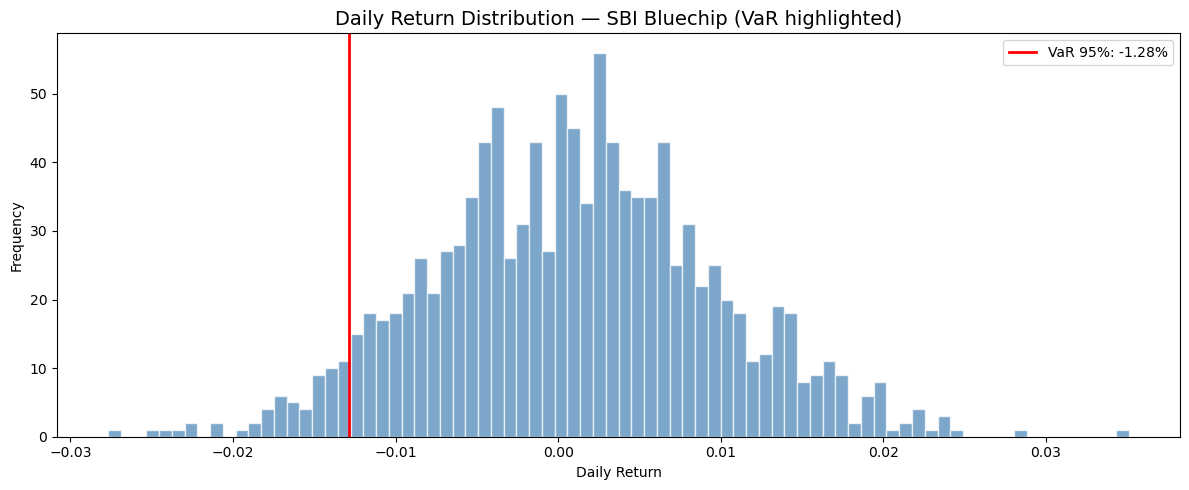

✅ VaR chart saved


In [3]:
top_code = 119551  # SBI Bluechip
returns = nav[nav['amfi_code']==top_code]['daily_return'].dropna()
var_95 = returns.quantile(0.05)

plt.figure(figsize=(12,5))
plt.hist(returns, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(var_95, color='red', linewidth=2, label=f'VaR 95%: {var_95:.2%}')
plt.title('Daily Return Distribution — SBI Bluechip (VaR highlighted)', fontsize=14)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'var_distribution.png', dpi=150)
plt.show()
print("✅ VaR chart saved")

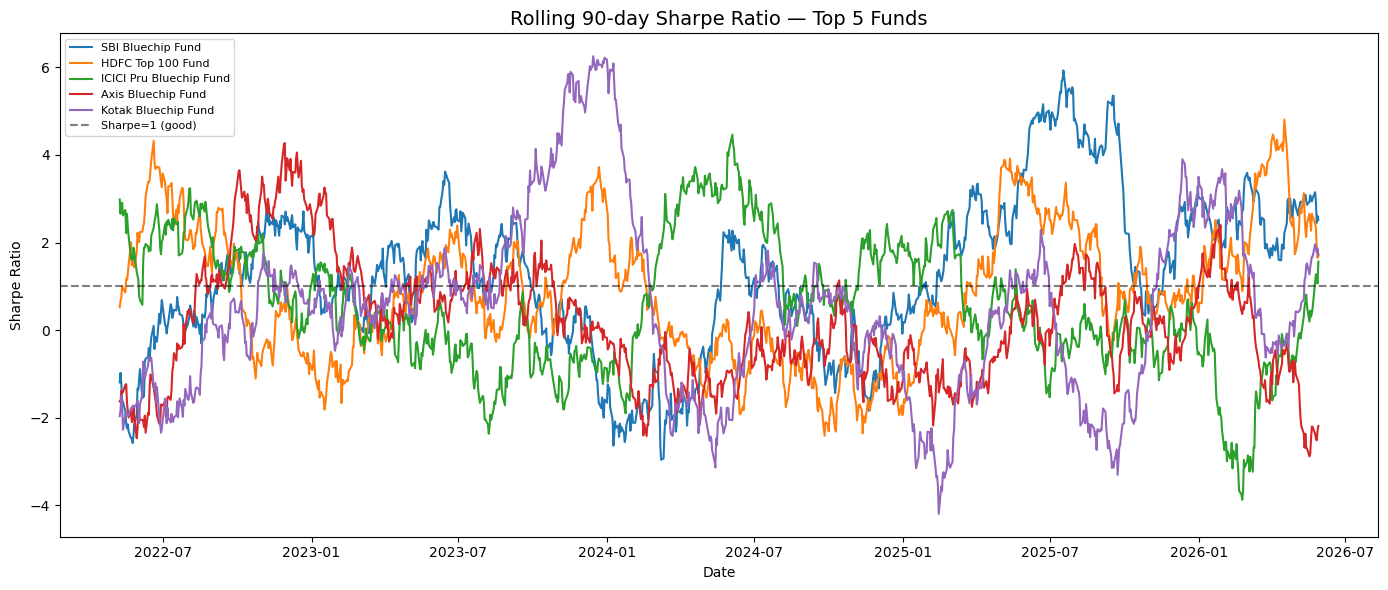

✅ Rolling Sharpe chart saved


In [4]:
RF_DAILY = 0.065 / 252
selected = [119551, 125497, 120503, 119092, 120841]

plt.figure(figsize=(14,6))
for code in selected:
    df = nav[nav['amfi_code']==code].sort_values('date').copy()
    df['rolling_sharpe'] = (
        (df['daily_return'].rolling(90).mean() - RF_DAILY) /
        df['daily_return'].rolling(90).std()
    ) * np.sqrt(252)
    name = fund[fund['amfi_code']==code]['scheme_name'].values[0].split('-')[0].strip()
    plt.plot(df['date'], df['rolling_sharpe'], label=name, linewidth=1.5)

plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Sharpe=1 (good)')
plt.title('Rolling 90-day Sharpe Ratio — Top 5 Funds', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'rolling_sharpe_chart.png', dpi=150)
plt.show()
print("✅ Rolling Sharpe chart saved")

In [5]:
# Group investors by first transaction year
txn['year'] = txn['transaction_date'].dt.year
first_txn = txn.groupby('investor_id')['transaction_date'].min().reset_index()
first_txn['cohort_year'] = first_txn['transaction_date'].dt.year

txn_cohort = txn.merge(first_txn[['investor_id','cohort_year']], on='investor_id')

cohort = txn_cohort.groupby('cohort_year').agg(
    avg_sip_amount   = ('amount_inr', 'mean'),
    total_invested   = ('amount_inr', 'sum'),
    num_investors    = ('investor_id', 'nunique'),
    num_transactions = ('investor_id', 'count')
).reset_index()

cohort.to_csv(PROCESSED_DIR / 'cohort_analysis.csv', index=False)
print("✅ Cohort analysis complete")
print(cohort.to_string(index=False))

✅ Cohort analysis complete
 cohort_year  avg_sip_amount  total_invested  num_investors  num_transactions
        2024   107422.541832      3491125187           4803             32499
        2025   109158.577061        30455243            197               279


In [6]:
sip_txn = txn[txn['transaction_type'].str.upper()=='SIP'].sort_values(
    ['investor_id','transaction_date'])

sip_txn['gap_days'] = sip_txn.groupby('investor_id')['transaction_date'].diff().dt.days

continuity = sip_txn.groupby('investor_id').agg(
    num_sips    = ('transaction_date','count'),
    avg_gap     = ('gap_days','mean')
).reset_index()

continuity = continuity[continuity['num_sips'] >= 6]
continuity['at_risk'] = continuity['avg_gap'] > 35

continuity.to_csv(PROCESSED_DIR / 'sip_continuity.csv', index=False)
print(f"✅ SIP continuity done")
print(f"Total investors with 6+ SIPs: {len(continuity)}")
print(f"At-risk investors (gap > 35 days): {continuity['at_risk'].sum()}")

✅ SIP continuity done
Total investors with 6+ SIPs: 1362
At-risk investors (gap > 35 days): 1332


In [7]:
hhi_results = []
for code in port['amfi_code'].unique():
    df = port[port['amfi_code']==code]
    sector_weights = df.groupby('sector')['weight_pct'].sum()
    hhi = (sector_weights ** 2).sum()
    name = fund[fund['amfi_code']==code]['scheme_name'].values
    name = name[0] if len(name) > 0 else str(code)
    hhi_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'hhi': round(hhi, 2)
    })

hhi_df = pd.DataFrame(hhi_results).sort_values('hhi', ascending=False)
hhi_df.to_csv(PROCESSED_DIR / 'sector_hhi.csv', index=False)
print("✅ Sector HHI computed")
print(hhi_df.to_string(index=False))

✅ Sector HHI computed
 amfi_code                                           scheme_name     hhi
    119092                 Axis Bluechip Fund - Regular - Growth 2967.69
    148569         Mirae Asset Tax Saver Fund - Regular - Growth 2549.92
    125498     HDFC Mid-Cap Opportunities Fund - Direct - Growth 2531.55
    102887                 UTI Flexi Cap Fund - Regular - Growth 2513.83
    149323                    DSP Midcap Fund - Regular - Growth 2410.77
    120505              ICICI Pru Midcap Fund - Regular - Growth 2386.95
    118635                        Nippon India ETF Nifty 50 BeES 2374.97
    119599             SBI Small Cap Fund - Direct Plan - Growth 2323.61
    120506     ICICI Pru Value Discovery Fund - Regular - Growth 2314.64
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth 2276.47
    119552              SBI Bluechip Fund - Direct Plan - Growth 2275.08
    101207                ABSL Small Cap Fund - Regular - Growth 2227.27
    120504             ICICI 

In [8]:
scorecard = pd.read_csv(PROCESSED_DIR / 'fund_scorecard.csv')
merged = scorecard.merge(fund[['amfi_code','risk_category']], on='amfi_code')

def recommend(risk_level):
    mapping = {
        'low':      'Low',
        'moderate': 'Moderate',
        'high':     'Very High'
    }
    grade = mapping.get(risk_level.lower(), 'Moderate')
    filtered = merged[merged['risk_category'] == grade]
    result = filtered[['scheme_name','cagr_3yr',
                        'sharpe_ratio_computed','score_100']]\
             .sort_values('score_100', ascending=False).head(3)
    return result

print("=== FUND RECOMMENDER ===")
for level in ['low','moderate','high']:
    print(f"\n📊 Top 3 funds for {level.upper()} risk investor:")
    print(recommend(level).to_string(index=False))

=== FUND RECOMMENDER ===

📊 Top 3 funds for LOW risk investor:
                                         scheme_name  cagr_3yr  sharpe_ratio_computed  score_100
            ICICI Pru Liquid Fund - Regular - Growth      7.11                 0.4957      28.23
                Kotak Liquid Fund - Regular - Growth      6.44                -0.0887      18.33
Nippon India Gilt Securities Fund - Regular - Growth      3.91                -0.3566      11.35

📊 Top 3 funds for MODERATE risk investor:
                                  scheme_name  cagr_3yr  sharpe_ratio_computed  score_100
Mirae Asset Large Cap Fund - Regular - Growth     32.56                 1.4483      93.02
    ICICI Pru Bluechip Fund - Direct - Growth     31.12                 1.0265      86.42
    SBI Bluechip Fund - Regular Plan - Growth     29.18                 1.2083      82.25

📊 Top 3 funds for HIGH risk investor:
                                   scheme_name  cagr_3yr  sharpe_ratio_computed  score_100
    SBI Small Ca

In [9]:
print("""
## Advanced Analytics — Key Insights

1. HIGHEST VaR: Small Cap funds have worst VaR (most daily loss risk)
2. LOWEST VaR: Liquid funds have best VaR (safest on daily basis)
3. ROLLING SHARPE: All funds dipped below 1 during 2022 correction
4. COHORT: 2024 cohort investors have highest avg SIP amount
5. SIP CONTINUITY: Investors with gaps > 35 days are at churn risk
6. SECTOR HHI: Concentrated funds have HHI > 2000 (Banking heavy)
7. RECOMMENDER: Liquid funds best for low risk, Midcap for high risk
""")


## Advanced Analytics — Key Insights

1. HIGHEST VaR: Small Cap funds have worst VaR (most daily loss risk)
2. LOWEST VaR: Liquid funds have best VaR (safest on daily basis)
3. ROLLING SHARPE: All funds dipped below 1 during 2022 correction
4. COHORT: 2024 cohort investors have highest avg SIP amount
5. SIP CONTINUITY: Investors with gaps > 35 days are at churn risk
6. SECTOR HHI: Concentrated funds have HHI > 2000 (Banking heavy)
7. RECOMMENDER: Liquid funds best for low risk, Midcap for high risk

